In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [72]:
# Data Generating Process
np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

In [73]:
n_bootstraps = 10000
bootstrapped_medians = np.zeros(n_bootstraps)

for i in range(n_bootstraps):
    resample = np.random.choice(driver_tips, size=len(driver_tips), replace=True)
    bootstrapped_medians[i] = np.median(resample)

ci_lower = np.percentile(bootstrapped_medians, 2.5)
ci_upper = np.percentile(bootstrapped_medians, 97.5)
median = np.median(driver_tips)

print(ci_lower)
print(ci_upper)
print(median)

# Unlike the normal standard intervals that tend to show a symmetric ball shape, this method shows
# the right-skew due to the median being .75 and the lower being a .265

0.2653018357387816
1.3635639228066991
0.7553316913699188


In [74]:
control = np.random.normal(loc=35.0, scale=5.0, size=500)
treatment = np.random.lognormal(mean=3.4, sigma=0.4, size=500)

difference = np.mean(control) - np.mean(treatment)

print(difference)

2.114716590374762


In [75]:
deliveries = np.concatenate([control, treatment])

n_iterations = 5000
simulated_diffs = np.zeros(n_iterations)

for i in range(n_iterations):
    shuffled = np.random.permutation(deliveries)
    group1, group2 = np.split(shuffled, 2)
    simulated_diffs[i] = np.mean(group1) - np.mean(group2)

empirical = np.mean(np.abs(simulated_diffs) >= np.abs(difference))
print(empirical)

0.0022


In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

df = pd.read_csv('swiftcart_loyalty.csv')
subscribers = df[df['subscriber'] == 1]['post_spend'].mean()
non_subscribers = df[df['subscriber'] == 0]['post_spend'].mean()

sdo = subscribers - non_subscribers
print(sdo)

X = df.drop(columns=['subscriber', 'post_spend'])
df['pros_score'] = LogisticRegression().fit(X, df['subscriber']).predict_proba(X)[:, 1]
sub, nonsub = df[df['subscriber'] == 1], df[df['subscriber'] == 0]  
nn = NearestNeighbors(n_neighbors=1).fit(nonsub[['pros_score']]).kneighbors(sub[['pros_score']])[1].flatten()
att = (sub['post_spend'].values - nonsub.iloc[nn]['post_spend'].values).mean()

print(att)

# The sdo being 17.57 shows that it is overstating the program's impact by ignoring that heavy spenders tend to
# lean towards subscribing. The propensity score being 9.91 shows that the values are being inflated and not
# showing the accurate results by leaving in tendencies and biases.

17.570669384523804
9.913855182824864


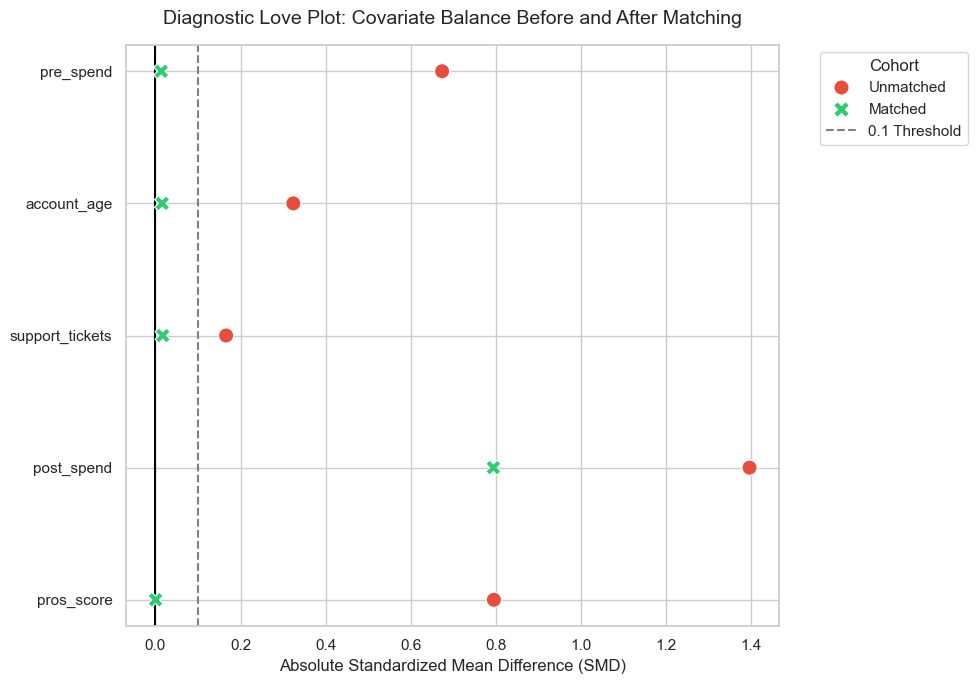

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_smd(df, treatment_col):
    """
    Calculates the absolute Standardized Mean Difference (Cohen's d) 
    for all covariates between treated and control groups.
    """
    # Isolate treated and control groups
    treated = df[df[treatment_col] == 1].drop(columns=[treatment_col])
    control = df[df[treatment_col] == 0].drop(columns=[treatment_col])
    
    # Calculate means and variances
    mean_t, mean_c = treated.mean(), control.mean()
    var_t, var_c = treated.var(), control.var()
    
    # Calculate pooled standard deviation and absolute SMD
    pooled_std = np.sqrt((var_t + var_c) / 2)
    smd = np.abs((mean_t - mean_c) / pooled_std)
    
    return smd

# Define your treatment indicator column (adjust 'treatment' if named differently)
treatment_col = 'subscriber'

# 1. Calculate SMDs for both states
smd_unmatched = calculate_smd(df_unmatched, treatment_col)
smd_matched = calculate_smd(df_matched, treatment_col)

# 2. Construct an optimized DataFrame for seaborn plotting
plot_df = pd.DataFrame({
    'Covariate': smd_unmatched.index,
    'Unmatched': smd_unmatched.values,
    'Matched': smd_matched.values
}).melt(
    id_vars='Covariate', 
    value_vars=['Unmatched', 'Matched'],
    var_name='Sample Status', 
    value_name='Absolute SMD'
)

# 3. Architect the visual space
plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid")

# Generate the dot plot
ax = sns.scatterplot(
    data=plot_df, 
    x='Absolute SMD', 
    y='Covariate', 
    hue='Sample Status',
    style='Sample Status', 
    s=120, 
    palette=['#e74c3c', '#2ecc71'], # Red for Unmatched, Green for Matched
    zorder=3
)

# Add diagnostic thresholds
plt.axvline(x=0.0, color='black', linestyle='-', zorder=1)
plt.axvline(x=0.1, color='gray', linestyle='--', zorder=2, label='0.1 Threshold')

# Aesthetic refinements
plt.title('Diagnostic Love Plot: Covariate Balance Before and After Matching', fontsize=14, pad=15)
plt.xlabel('Absolute Standardized Mean Difference (SMD)', fontsize=12)
plt.ylabel('')
plt.legend(title='Cohort', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()